In [9]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", google_api_key=api_key, temperature=0.7)

Google api key is set


In [10]:
from typing import TypedDict, List, Annotated, Literal
from langgraph.graph.message import add_messages, BaseMessage
from langchain_core.documents import Document
from langchain_core.messages import ToolMessage
from pydantic import BaseModel, Field

class ItemSelection(BaseModel):
    item_id: int = Field(
        description="The item_id of the selected item. Must be the database item ID."
    )
    item_name: str = Field(
        description="The exact product name of the selected item."
    )

class support_schema(BaseModel):
    question: str
    ticket_id: str | None = Field(description="id used to fetch ticket support issues to user")
    
    type: Literal["Cancellation", "Refund", "Return", "Warranty", "Shipping"]
    customerID: str | None = Field(
        default=None,
        description="Customer ID"
    )
    orderID: str | None = Field(
        default=None,
        description="Order ID"
    )
    exists: Literal["Yes", "No"]
    status: Literal['open', 'in_progress', 'resolved', 'closed']
    priority: int = Field(description="0 means normal no priority given more then 0 means user needs support urgent")
    description: str = Field(description="Info about the issue user is facing and the ticket generated")
    item_list: list[ItemSelection] 

class llm_schema(BaseModel):
    type: Literal["Cancellation", "Refund", "Return", "Warranty", "Shipping"]
    question: str = Field(description="Reframed sentence into which type of poilcy(Cancellation, Refund, Return, Warranty, shipping) should be check for eligibility")
    product_info: str = Field(description="Product name, product buying date(in dd/mm/yyy format), product/order id etc")
    eligibility: Literal["Eligible", "Not Eligible"]
    answer: str

class graph_schema(TypedDict):
    query: str
    document: List[Document]
    product_info: str
    policy_question: str
    eligibility: Literal["Eligible", "Not Eligible"]
    item_list: list
    ticket_id: str | None
    tool_calls: list
    tool_result: list[ToolMessage]
    description: str
    status: Literal['open', 'in_progress', 'resolved', 'closed']
    priority: int = Field(description="0 means normal no priority given more then 0 means user needs support urgent")
    type: Literal["Cancellation", "Refund", "Return", "Warranty", "Shipping"]
    conversation: Annotated[List[BaseMessage], add_messages]
    answer: str


In [11]:
llm_with_schema = llm.with_structured_output(llm_schema)
llm_with_support_schema = llm.with_structured_output(support_schema)

In [12]:
def get_order_item(id) -> graph_schema:
    orderData = order.fetch_order_by_id(id)
    
    if len(orderData) == 0:
        return {
            "answer": "I couldn't find an order with that order ID.",
        }
            
    items = order_item.fetch_order_items_by_id(id)
    if len(items) == 0:
        return {
            "answer": "No item found with the specified id"
        }
    
    elif len(items) == 1:
        return {
            "item_list": items
        }

    item_list = [
        {
            "item_id": i[0],
            "item_name": i[2],
            "item_category": i[3],
            "item_price": i[5]
        }
        for i in items
    ]
    
    return {
        "answer": "Multiple items found in your order specify which one or all?",
        "item_list": item_list
    }

In [13]:
from Support_Tools.tools import create_ticket, update_ticket, cancel_order, process_refund, get_ticket

tools = [create_ticket, update_ticket, cancel_order, process_refund, get_ticket]

llm_with_tools = llm.bind_tools(tools)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
import os
from langchain_core.messages import ToolMessage
from RagIntegration import RagRetriever
from datetime import datetime
from DB_Manager.customerDB import CustomerDatabaseManager
from DB_Manager.orderDB import OrderDatabaseManager
from DB_Manager.orderItemsDB import OrderItemDatabaseManager

retriever = RagRetriever()
customer = CustomerDatabaseManager()
order = OrderDatabaseManager()
order_item = OrderItemDatabaseManager()

def track_db_node(state: graph_schema) -> graph_schema:
    user_query = state["conversation"]
    result = llm_with_support_schema.invoke(user_query)
    print(result)

    if result.ticket_id:
        return{
            "ticket_id": result.ticket_id
        }

    elif result.item_list and result.item_list[0].item_id:
        print(f"Your selected Item{result.item_list}")

        selected_product = result.item_list[0]
        
        product_info = order_item.fetch_item_by_id(selected_product.item_id)
        
        product_info = {
            "delivery_date": product_info[9],
            "delivery_status": product_info[10],
            "product_id": product_info[0],
            "product_name": product_info[2],
            "product_category": product_info[3],
            "product_price": product_info[5]
        }
        
        delivery_date = datetime.fromisoformat(product_info['delivery_date'])
        current_date = datetime.now()
        
        print(f"Today's date: {current_date} and delivery date: {delivery_date}")
        
        if delivery_date > current_date and result.type == "Return":
            return {
                "answer": "Order is not delivered yet if you want you can cancel it instead of return"
                }
        
        print(f"Your product info: {product_info}")
        return {
            "type": result.type,
            "description": result.description,
            "status": result.status,
            "priority": result.priority,
            "product_info": product_info,
            "query": result.question
        }

    elif result.orderID:
        return get_order_item(result.orderID)
        
    
    elif result.customerID:
        orderData = order.fetch_order_by_customer_id(result.customerID)
        if len(orderData) == 0:
            return {
                "answer": "You don't have any orders",
            }
        
        elif len(orderData) > 1:
            return {
                "answer": "You have multiple orders provide order id"
            }
        else:
            return get_order_item(orderData[0].orderID)

    
    else:
        return {
            "answer": "Please provide your order ID or customer ID."
        }
    
def decision_node(state: graph_schema) -> str:
    answer = state['answer']

    if answer:
        return "end"
    
    elif state['ticket_id']:
        return "support_node"
    
    else:
        return "retriever_node"


def retriever_node(state:graph_schema) -> graph_schema:

    query = state["query"]
    result = llm_with_schema.invoke(query)
    print(result)
    policy_dir = "Policies"

    policy_files = {
        "Return": "RETURN_POLICY.pdf",
        "Cancellation": "CANCELLATION_POLICY.pdf",
        "Refund": "REFUND_POLICY.pdf",
        "Warranty": "WARRANTY_POLICY.pdf",
        "Shipping": "SHIPPING_POLICY.pdf",
        "Payment": "PAYMENT_FAQ.pdf"
    }

    file_path = os.path.join(
        policy_dir,
        policy_files[result.type]
    )

    print("Loading:", file_path)
    print("Exists:", os.path.exists(file_path))

    retriever.file_loader(file_path)
    retriever.text_splitting()
    response = retriever.vector_embedding(result.question)

    return {
        "policy_question": result.question,
        "document": response
    }

def generator_node(state: graph_schema) -> graph_schema:
    user_query = state["query"]
    document = state["document"]
    question = state["policy_question"]
    product_info = state["product_info"]

    context = "\n\n".join(docs.page_content for docs in document)

    current_date = datetime.now().isoformat()

    prompt = ChatPromptTemplate.from_messages([
    ("system", """
        You are a customer support assistant for an e-commerce company.

        Your task is to answer the user's original question using:
        1. The retrieved company policy as the authoritative source for policy rules.
        2. The customer's product/order information when determining eligibility.
        3. The original user question to understand what the customer wants.

        Instructions:
        - Use the retrieved policy as the source of truth for company rules.
        - Use the product/order information only for facts about the customer's specific product or order.
        - Compare the customer's product/order information against the requirements in the policy when determining eligibility.
        - Do not invent policy rules, customer information, order information, dates, prices, or eligibility conditions.
        - If the policy does not provide enough information to determine eligibility, clearly state that you cannot determine eligibility from the available information.
        - If the customer's product/order information is missing, ask the customer for the required information.
        - If the customer is eligible, clearly explain why based on the policy.
        - If the customer is not eligible, clearly explain which policy requirement is not satisfied.
        - The date provided to you is either delivery date
        - Answer the original user's question, not merely the reframed policy question.
        - Also return eligibility if eligible or not
        - Keep the response clear and direct.
        - Do not mention the RAG system, retrieval process, embeddings, vector database, or internal tools.
        
        Retrieved Policy Context:
        {context}

        Customer/Product Information:
        {product_info}

        Policy_question:
        {question}

        today_date:
        {current_date}
    """),

    ("user", """
        Original Customer Question:
        {user_query}
    """)
])

    chain = prompt | llm_with_schema

    result = chain.invoke({"context": context, "product_info": product_info, "question": question, "current_date": current_date, "user_query": user_query})
    print(result.answer)
    return {
        "answer": result.answer,
        "eligibility": result.eligibility
    }

def support_needed(state: graph_schema) -> str:
    if state['eligibility'] == "Eligible":
        return "support_node"
    else:
        return "end"

def support_node(state: graph_schema) -> graph_schema:
    query = state["conversation"]
    result = llm_with_tools.invoke(query)

    return {
        "tool_calls": result.tool_calls
    }

def tool_node(state: graph_schema) -> graph_schema:
    tool_calls = state['tool_calls']

    tool_name = {tool.name: tool for tool in tools}

    tool_result = []
    for tool_call in tool_calls:
        tool = tool_name[tool_call["name"]]
        observation = decide_tool(state, tool, tool_call["name"], tool_call["args"])
        tool_result.append(ToolMessage(content=str(observation), tool_call_id=tool_call["id"]))

    return {
        "tool_result": tool_result
    }

def decide_tool(state: graph_schema, tool, tool_name, tool_args):
    
    if tool_name == "create_ticket":
        print("Create Ticket tool raised")
        item_id = tool_args['item_id']
        response = tool.invoke({"ticket_type": state['type'], "description": state['description'], "item_id": item_id, "status": state['status']})
        print(f"Response after create ticket: {response}")

    elif tool_name == "update_ticket":
        print("Update Ticket tool raised")

    elif tool_name == "cancel_order":
        item_id = tool_args['item_id']
        response = order_item.fetch_item_by_id(item_id)
        order_id = response[1]
        response = tool.invoke({"order_id":order_id, "item_id":item_id})
        print(f"Response after cancel order: {response}")

    elif tool_name == "process_refund":
        print("Create Ticket tool raised")

    else:
        print("Get ticket tool raised")

def response_node(state: graph_schema) -> graph_schema:

    tool_result = "\n".join(
        message.content for message in state["tool_result"]
    )

    prompt = f"""
    Original request:
    {state["conversation"]}

    Previous analysis:
    {state["answer"]}

    Tool execution result:
    {tool_result}

    Give the customer a clear final response.
    """

    result = llm.invoke(prompt)

    return {
        "answer": result.content[0]['text']
    }


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4525.60it/s]


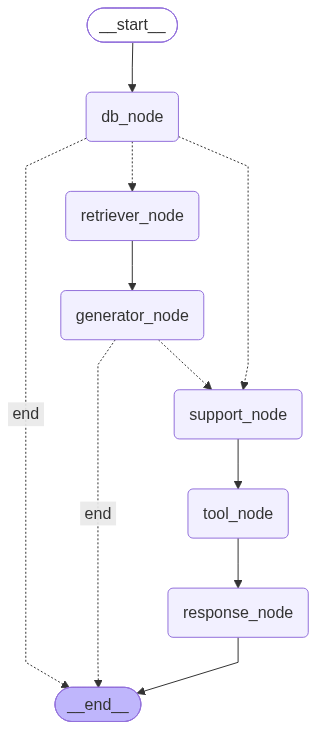

In [15]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("retriever_node", retriever_node)
graph.add_node("db_node", track_db_node)
graph.add_node("generator_node", generator_node)
graph.add_node("support_node", support_node)
graph.add_node("tool_node", tool_node)
graph.add_node("response_node", response_node)

graph.add_edge(START, "db_node")
graph.add_conditional_edges("db_node", decision_node, {"retriever_node": "retriever_node", "support_node": "support_node", "end": END})
graph.add_edge("retriever_node", "generator_node")
graph.add_conditional_edges("generator_node", support_needed, {"support_node": "support_node", "end": END})
graph.add_edge("support_node", "tool_node")
graph.add_edge("tool_node", "response_node")
graph.add_edge("response_node", END)

customer_support_agent = graph.compile()

customer_support_agent

In [16]:
from langchain_core.messages import HumanMessage, AIMessage
from memory import LocalMemory
#ORDTHCG
#ORDFFZ7
memory = LocalMemory()

conversation = []
while True:
    user_query = input("Enter your query (stop to end)...")
    if user_query.lower() == "stop":
        print("Execution Stopped...")
        break

    conversation.append(HumanMessage(content=user_query))

    response = customer_support_agent.invoke({
    "query": user_query,
    "document": [],
    "policy_question":"",
    "product_info": "",
    "eligible": "",
    "answer": "",
    "conversation": conversation,
    "item_list": []
})

    print(response['answer'])
    if response['item_list']:
        print(f"Items:")

        for index, item in enumerate(response["item_list"], start=1):
            print(f"Id: {item['item_id']}")
            print(f"item name: {item['item_name']}")
            print(f"   Category: {item['item_category']}")
            print(f"   Price: ₹{item['item_price']:,.2f}")
            print()

        print("Specify atleast id and name")

    conversation.append(AIMessage(content=response['answer']))
    memory.save_memory(conversation)


question='what is the status of ticket id TCK9027' ticket_id='TCK9027' type='Shipping' customerID=None orderID=None exists='Yes' status='open' priority=0 description='The user is inquiring about the current status of their support ticket TCK9027.' item_list=[]


KeyError: 'description'

In [ ]:
from memory import LocalMemory

memory = LocalMemory()

result = memory.load_memory()

for conversation in result[-5:]:
    print(conversation["page_content"])
    print("-" * 50)


HUMAN: want to return order of id ORDTHCG
AI: Multiple items found in your order specify which one or all?
--------------------------------------------------
HUMAN: want to return order of id ORDTHCG
AI: Multiple items found in your order specify which one or all?
HUMAN: Dell Inspiron 15 of id 1
AI: Your Dell Inspiron 15 is not eligible for return because the delivery date was 2026-08-19, which exceeds the 7-day return window specified in our policy.
--------------------------------------------------
HUMAN: want to return my order of id ORDTHCG
AI: Multiple items found in your order specify which one or all?
--------------------------------------------------
HUMAN: want to return my order of id ORDTHCG
AI: Multiple items found in your order specify which one or all?
HUMAN: Dell Inspiron 15 of id 1
AI: To proceed with your return for the Dell Inspiron 15 (ID: 1) from order ORDTHCG, please follow these steps:

1. **Prepare the item:** Ensure the laptop is in its original packaging, inclu

In [ ]:
from DB_Manager.customerDB import CustomerDatabaseManager
from DB_Manager.orderDB import OrderDatabaseManager
from DB_Manager.orderItemsDB import OrderItemDatabaseManager

customer = CustomerDatabaseManager()
order = OrderDatabaseManager()
order_item = OrderItemDatabaseManager()
#ORDFFZ7

result = order.fetch_order_by_id("ORDTHCG")
result

[('ORDTHCG',
  101,
  '2026-08-16',
  '2026-08-19',
  'Delivered',
  53000.0,
  'UPI',
  1,
  'Dell Inspiron 15',
  'Laptop',
  1,
  50000.0,
  'Good'),
 ('ORDTHCG',
  101,
  '2026-08-16',
  '2026-08-19',
  'Delivered',
  53000.0,
  'UPI',
  2,
  'Logitech Wireless Mouse',
  'Accessories',
  1,
  1000.0,
  'Good'),
 ('ORDTHCG',
  101,
  '2026-08-16',
  '2026-08-19',
  'Delivered',
  53000.0,
  'UPI',
  3,
  'HP Wireless Keyboard',
  'Accessories',
  1,
  2000.0,
  'Good')]